# ECal/TriggerPad Input Preprocessing Audit

This notebook inspects the ROOT-derived inputs that become the canonical tensor-event feature layout:

```text
[is_ecal, is_tpad, ecal_x, ecal_y, ecal_z, ecal_energy, tpad_centroid, tpad_pe]
```

The goal is to decide which preprocessing transforms are worth baking into sharded tensorization before launching large Cosmos `sbatch` preprocessing jobs. The notebook samples ROOT files, plots raw distributions, tries sensible transforms, and keeps targets/truth fields separate from model input features.

## Working Assumptions

- `ecal_energy` is reconstructed ECal RecHit energy and is an input feature. It is a good candidate for `log1p(max(x, 0))`.
- `tpad_pe` is also non-negative detector intensity-like context and may be skewed; inspect it before deciding whether to log-transform it.
- `ecal_x`, `ecal_y`, `ecal_z`, and `tpad_centroid` are geometry coordinates. Usually keep these raw in shards and normalize later from train-split statistics, unless you choose a fixed detector-coordinate scaling.
- `is_ecal` and `is_tpad` are binary detector-type indicators; do not transform them.
- `physical_y`, `canonical_y`, `fraction_target`, contribution truth, and noise labels are targets/metadata; do not apply feature transforms to them.

In [52]:
from __future__ import annotations

from pathlib import Path
import os
import sys

import awkward as ak
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name != "ml_ldmx":
    candidates = [PROJECT_ROOT, *PROJECT_ROOT.parents]
    PROJECT_ROOT = next((path for path in candidates if (path / "src/ml_ldmx").exists()), PROJECT_ROOT)
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from ml_ldmx.io.root_files import find_root_files
from ml_ldmx.io.root_reader import iter_ecal_rechits_with_truth_and_triggerpad_context
from ml_ldmx.datasets.tensorize import tensorize_ecal_with_triggerpad_context

FIGURE_DIR = PROJECT_ROOT / "figures/notebooks/input_preprocessing_audit"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

DATASET_ROOT = Path(os.environ.get("ML_LDMX_ROOT_DATA", PROJECT_ROOT / "data/ldmx_overlay_events_700k"))
SOURCE_SPECS = [
    (2, "2e", DATASET_ROOT / "2e/events"),
    (3, "3e", DATASET_ROOT / "3e/events"),
]

MAX_ROOT_FILES_PER_SOURCE = int(os.environ.get("ML_LDMX_AUDIT_MAX_ROOT_FILES", "2"))
MAX_EVENTS_PER_ROOT_FILE = int(os.environ.get("ML_LDMX_AUDIT_MAX_EVENTS_PER_ROOT_FILE", "200"))
READ_STEP_SIZE = int(os.environ.get("ML_LDMX_AUDIT_READ_STEP_SIZE", "100"))
VALID_LABELS = (1, 2, 3)

print(f"project root: {PROJECT_ROOT}")
print(f"dataset root: {DATASET_ROOT}")
print(f"figure output: {FIGURE_DIR}")
print(f"max ROOT files/source: {MAX_ROOT_FILES_PER_SOURCE}")
print(f"max events/ROOT file: {MAX_EVENTS_PER_ROOT_FILE}")

project root: /Users/eliotmontesinopetren/src/mpetren-msceng-ldmx/ml_ldmx
dataset root: /Users/eliotmontesinopetren/src/mpetren-msceng-ldmx/ml_ldmx/data/ldmx_overlay_events_700k
figure output: /Users/eliotmontesinopetren/src/mpetren-msceng-ldmx/ml_ldmx/figures/notebooks/input_preprocessing_audit
max ROOT files/source: 2
max events/ROOT file: 200


In [53]:
feature_catalog = pd.DataFrame(
    [
        {
            "feature": "is_ecal",
            "source": "constructed in tensorize_ecal_with_triggerpad_context",
            "tensor_column": 0,
            "dtype": "float32 binary 0/1",
            "role": "detector type indicator",
            "candidate_transform": "none",
        },
        {
            "feature": "is_tpad",
            "source": "constructed in tensorize_ecal_with_triggerpad_context",
            "tensor_column": 1,
            "dtype": "float32 binary 0/1",
            "role": "detector type indicator",
            "candidate_transform": "none",
        },
        {
            "feature": "ecal_x",
            "source": "EcalRecHits_overlay.xpos_",
            "tensor_column": 2,
            "dtype": "float32",
            "role": "ECal hit geometry",
            "candidate_transform": "usually train-split z-score or fixed detector scaling, not log",
        },
        {
            "feature": "ecal_y",
            "source": "EcalRecHits_overlay.ypos_",
            "tensor_column": 3,
            "dtype": "float32",
            "role": "ECal hit geometry and canonical target ordering axis",
            "candidate_transform": "usually train-split z-score or fixed detector scaling, not log",
        },
        {
            "feature": "ecal_z",
            "source": "EcalRecHits_overlay.zpos_",
            "tensor_column": 4,
            "dtype": "float32",
            "role": "ECal layer/depth geometry proxy",
            "candidate_transform": "usually train-split z-score or fixed detector scaling; possible layer encoding is a separate study",
        },
        {
            "feature": "ecal_energy",
            "source": "EcalRecHits_overlay.energy_",
            "tensor_column": 5,
            "dtype": "float32 non-negative expected",
            "role": "reconstructed hit energy input",
            "candidate_transform": "log1p(clamp_min(x, 0)) is likely useful for right skew",
        },
        {
            "feature": "tpad_centroid",
            "source": "TriggerPadTracks_overlay.centroid_",
            "tensor_column": 6,
            "dtype": "float32",
            "role": "TriggerPadTracks 1D position context",
            "candidate_transform": "usually align with coordinate normalization, not log",
        },
        {
            "feature": "tpad_pe",
            "source": "TriggerPadTracks_overlay.pe_",
            "tensor_column": 7,
            "dtype": "float32 non-negative expected",
            "role": "TriggerPadTracks intensity context",
            "candidate_transform": "inspect skew; log1p may be useful if heavy-tailed",
        },
    ]
)
feature_catalog

,feature,source,tensor_column,dtype,role,candidate_transform
0,is_ecal,constructed in tensorize_ecal_with_triggerpad_...,0,float32 binary 0/1,detector type indicator,none
1,is_tpad,constructed in tensorize_ecal_with_triggerpad_...,1,float32 binary 0/1,detector type indicator,none
2,ecal_x,EcalRecHits_overlay.xpos_,2,float32,ECal hit geometry,usually train-split z-score or fixed detector ...
3,ecal_y,EcalRecHits_overlay.ypos_,3,float32,ECal hit geometry and canonical target orderin...,usually train-split z-score or fixed detector ...
4,ecal_z,EcalRecHits_overlay.zpos_,4,float32,ECal layer/depth geometry proxy,usually train-split z-score or fixed detector ...
5,ecal_energy,EcalRecHits_overlay.energy_,5,float32 non-negative expected,reconstructed hit energy input,"log1p(clamp_min(x, 0)) is likely useful for ri..."
6,tpad_centroid,TriggerPadTracks_overlay.centroid_,6,float32,TriggerPadTracks 1D position context,"usually align with coordinate normalization, n..."
7,tpad_pe,TriggerPadTracks_overlay.pe_,7,float32 non-negative expected,TriggerPadTracks intensity context,inspect skew; log1p may be useful if heavy-tailed


In [54]:
def _safe_float_array(values):
    arr = np.asarray(values, dtype=np.float64)
    return arr[np.isfinite(arr)]


def _dominant_origin_and_total_edep(edeps, origins):
    if len(edeps) == 0 or len(edeps) != len(origins):
        return -1, 0.0
    edeps_np = np.asarray(edeps, dtype=np.float64)
    total = float(edeps_np.sum())
    if edeps_np.size == 0:
        return -1, total
    return int(origins[int(np.argmax(edeps_np))]), total


def describe_numeric(df, columns):
    rows = []
    for column in columns:
        values = _safe_float_array(df[column].dropna())
        if values.size == 0:
            rows.append({"feature": column, "n": 0})
            continue
        rows.append(
            {
                "feature": column,
                "n": int(values.size),
                "min": float(np.min(values)),
                "p01": float(np.quantile(values, 0.01)),
                "p05": float(np.quantile(values, 0.05)),
                "median": float(np.median(values)),
                "mean": float(np.mean(values)),
                "p95": float(np.quantile(values, 0.95)),
                "p99": float(np.quantile(values, 0.99)),
                "max": float(np.max(values)),
                "std": float(np.std(values)),
                "skew": float(pd.Series(values).skew()),
                "negative_count": int(np.sum(values < 0)),
                "zero_count": int(np.sum(values == 0)),
            }
        )
    return pd.DataFrame(rows)


def standardize(values):
    values = _safe_float_array(values)
    std = values.std()
    if std < 1e-12:
        return values * 0.0
    return (values - values.mean()) / std


def robust_standardize(values):
    values = _safe_float_array(values)
    q25, q75 = np.quantile(values, [0.25, 0.75])
    iqr = q75 - q25
    if iqr < 1e-12:
        return values * 0.0
    return (values - np.median(values)) / iqr


def log1p_nonnegative(values):
    return np.log1p(np.clip(_safe_float_array(values), a_min=0.0, a_max=None))


def sqrt_nonnegative(values):
    return np.sqrt(np.clip(_safe_float_array(values), a_min=0.0, a_max=None))


def plot_hist_grid(df, columns, bins=80, transform=None, title_prefix="", filename=None):
    ncols = 2
    nrows = int(np.ceil(len(columns) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.5 * nrows))
    axes = np.asarray(axes).reshape(-1)
    for ax, column in zip(axes, columns):
        values = _safe_float_array(df[column].dropna())
        label = column
        if transform is not None:
            values = transform(values)
            label = f"{transform.__name__}({column})"
        ax.hist(values, bins=bins, alpha=0.8)
        ax.set_title(label)
        ax.set_ylabel("count")
        ax.grid(alpha=0.2)
    for ax in axes[len(columns):]:
        ax.axis("off")
    if title_prefix:
        fig.suptitle(title_prefix, y=1.01, fontsize=14)
    fig.tight_layout()
    if filename:
        fig.savefig(FIGURE_DIR / filename, dpi=180, bbox_inches="tight")
    return fig


def plot_transform_comparison(values, feature_name, bins=100, filename=None):
    values = _safe_float_array(values)
    transforms = {
        "raw": values,
        "log1p(clamp_min)": log1p_nonnegative(values),
        "sqrt(clamp_min)": sqrt_nonnegative(values),
        "standard z-score": standardize(values),
        "robust median/IQR": robust_standardize(values),
    }
    fig, axes = plt.subplots(1, len(transforms), figsize=(5 * len(transforms), 4))
    rows = []
    for ax, (name, transformed) in zip(axes, transforms.items()):
        ax.hist(transformed, bins=bins, alpha=0.8)
        ax.set_title(name)
        ax.grid(alpha=0.2)
        rows.append(
            {
                "transform": name,
                "min": float(np.min(transformed)),
                "median": float(np.median(transformed)),
                "mean": float(np.mean(transformed)),
                "p99": float(np.quantile(transformed, 0.99)),
                "max": float(np.max(transformed)),
                "std": float(np.std(transformed)),
                "skew": float(pd.Series(transformed).skew()),
            }
        )
    fig.suptitle(f"Transform comparison for {feature_name}", y=1.02, fontsize=14)
    fig.tight_layout()
    if filename:
        fig.savefig(FIGURE_DIR / filename, dpi=180, bbox_inches="tight")
    return pd.DataFrame(rows), fig

In [55]:
ecal_rows = []
tpad_rows = []
event_rows = []
sampled_events = []

for electron_count, source_label, source_dir in SOURCE_SPECS:
    if not source_dir.exists():
        print(f"skip missing source: {source_label} {source_dir}")
        continue
    root_files = find_root_files(source_dir)[:MAX_ROOT_FILES_PER_SOURCE]
    print(f"{source_label}: {len(root_files)} ROOT file(s) selected from {source_dir}")
    for root_file in root_files:
        for local_entry, event in iter_ecal_rechits_with_truth_and_triggerpad_context(
            root_file,
            max_events=MAX_EVENTS_PER_ROOT_FILE,
            step_size=READ_STEP_SIZE,
        ):
            if len(sampled_events) < 3:
                sampled_events.append((source_label, root_file.name, local_entry, event))

            energies = np.asarray(event["energy"], dtype=np.float64)
            noise_flags = np.asarray(event.get("noise_flag", [False] * len(energies)), dtype=bool)
            tpad = event.get("trigger_pad_tracks", {})
            tpad_centroid = np.asarray(tpad.get("centroid", []), dtype=np.float64)
            tpad_pe = np.asarray(tpad.get("pe", []), dtype=np.float64)

            event_rows.append(
                {
                    "source_label": source_label,
                    "electron_count": electron_count,
                    "root_file": root_file.name,
                    "source_entry": int(local_entry),
                    "n_ecal_hits": int(len(energies)),
                    "n_noise_hits": int(noise_flags.sum()),
                    "noise_fraction": float(noise_flags.mean()) if len(noise_flags) else np.nan,
                    "n_tpad_tracks": int(len(tpad_pe)),
                    "ecal_total_energy": float(np.nansum(energies)) if len(energies) else 0.0,
                    "ecal_total_non_noise_energy": float(np.nansum(energies[~noise_flags])) if len(energies) else 0.0,
                    "ecal_max_energy": float(np.nanmax(energies)) if len(energies) else np.nan,
                    "tpad_total_pe": float(np.nansum(tpad_pe)) if len(tpad_pe) else 0.0,
                    "tpad_max_pe": float(np.nanmax(tpad_pe)) if len(tpad_pe) else np.nan,
                }
            )

            for hit_idx, (x, y, z, energy, is_noise, edeps, origins, n_contribs) in enumerate(
                zip(
                    event["x"],
                    event["y"],
                    event["z"],
                    event["energy"],
                    event.get("noise_flag", [False] * len(event["energy"])),
                    event.get("edep_contribs", [[] for _ in event["energy"]]),
                    event.get("origin_id_contribs", [[] for _ in event["energy"]]),
                    event.get("n_contribs", [0] * len(event["energy"])),
                )
            ):
                dominant_origin, total_edep = _dominant_origin_and_total_edep(edeps, origins)
                ecal_rows.append(
                    {
                        "source_label": source_label,
                        "electron_count": electron_count,
                        "root_file": root_file.name,
                        "source_entry": int(local_entry),
                        "hit_idx": hit_idx,
                        "ecal_x": float(x),
                        "ecal_y": float(y),
                        "ecal_z": float(z),
                        "ecal_energy": float(energy),
                        "ecal_energy_log1p": float(np.log1p(max(float(energy), 0.0))),
                        "is_noise": bool(is_noise),
                        "n_contribs": int(n_contribs),
                        "dominant_origin": dominant_origin,
                        "total_truth_edep": total_edep,
                    }
                )

            for track_idx, (centroid, pe) in enumerate(zip(tpad_centroid, tpad_pe)):
                tpad_rows.append(
                    {
                        "source_label": source_label,
                        "electron_count": electron_count,
                        "root_file": root_file.name,
                        "source_entry": int(local_entry),
                        "track_idx": track_idx,
                        "tpad_centroid": float(centroid),
                        "tpad_pe": float(pe),
                        "tpad_pe_log1p": float(np.log1p(max(float(pe), 0.0))),
                    }
                )

ecal_df = pd.DataFrame(ecal_rows)
tpad_df = pd.DataFrame(tpad_rows)
event_df = pd.DataFrame(event_rows)

print(f"sampled events: {len(event_df):,}")
print(f"sampled ECal hits: {len(ecal_df):,}")
print(f"sampled TriggerPadTracks: {len(tpad_df):,}")

display(event_df.head())
display(ecal_df.head())
display(tpad_df.head())

2e: 1 ROOT file(s) selected from /Users/eliotmontesinopetren/src/mpetren-msceng-ldmx/ml_ldmx/data/ldmx_overlay_events_700k/2e/events
3e: 1 ROOT file(s) selected from /Users/eliotmontesinopetren/src/mpetren-msceng-ldmx/ml_ldmx/data/ldmx_overlay_events_700k/3e/events
sampled events: 400
sampled ECal hits: 121,041
sampled TriggerPadTracks: 915


,source_label,electron_count,root_file,source_entry,n_ecal_hits,n_noise_hits,noise_fraction,n_tpad_tracks,ecal_total_energy,ecal_total_non_noise_energy,ecal_max_energy,tpad_total_pe,tpad_max_pe
0,2e,2,events_1.root,0,218,0,0.0,2,16806.867935,16806.867935,1047.076660,400.333328,237.333328
1,2e,2,events_1.root,1,286,0,0.0,2,16268.010456,16268.010456,746.430908,316.000000,173.666672
2,2e,2,events_1.root,2,220,0,0.0,2,15664.375979,15664.375979,772.348633,307.333328,169.000000
3,2e,2,events_1.root,3,250,0,0.0,2,16177.493514,16177.493514,886.386719,240.666664,147.000000
4,2e,2,events_1.root,4,246,0,0.0,2,17158.371303,17158.371303,834.551208,342.333328,176.333328


,source_label,electron_count,root_file,source_entry,hit_idx,ecal_x,ecal_y,ecal_z,ecal_energy,ecal_energy_log1p,is_noise,n_contribs,dominant_origin,total_truth_edep
0,2e,2,events_1.root,0,0,-9.631728,8.341321,247.582001,1.939171,1.078128,False,1,2,0.103892
1,2e,2,events_1.root,0,1,-2.407932,4.170660,247.582001,4.093806,1.628025,False,2,1,0.218379
2,2e,2,events_1.root,0,2,-4.815864,8.341321,256.161987,10.154853,2.411875,False,2,2,0.272798
3,2e,2,events_1.root,0,3,9.631728,-8.341321,256.161987,1.624776,0.964996,False,1,2,0.046689
4,2e,2,events_1.root,0,4,16.855524,29.194624,256.161987,5.280524,1.837453,False,1,1,0.149114


,source_label,electron_count,root_file,source_entry,track_idx,tpad_centroid,tpad_pe,tpad_pe_log1p
0,2e,2,events_1.root,0,0,27.652262,237.333328,5.473670
1,2e,2,events_1.root,0,1,29.000000,163.000000,5.099866
2,2e,2,events_1.root,1,0,14.527537,142.333328,4.965173
3,2e,2,events_1.root,1,1,43.455387,173.666672,5.162879
4,2e,2,events_1.root,2,0,35.324528,138.333328,4.936869


In [56]:
if not sampled_events:
    raise RuntimeError("No events were sampled. Check DATASET_ROOT or ML_LDMX_ROOT_DATA.")

source_label, root_name, source_entry, example_event = sampled_events[0]
raw_tensors = tensorize_ecal_with_triggerpad_context(
    example_event,
    valid_labels=VALID_LABELS,
    filter_noise=False,
    supervise_noise=True,
    ecal_energy_transform="raw",
)
log_tensors = tensorize_ecal_with_triggerpad_context(
    example_event,
    valid_labels=VALID_LABELS,
    filter_noise=False,
    supervise_noise=True,
    ecal_energy_transform="log1p",
)

field_rows = []
for key, value in raw_tensors.items():
    if isinstance(value, torch.Tensor):
        field_rows.append(
            {
                "field": key,
                "dtype": str(value.dtype),
                "shape": tuple(value.shape),
                "role": "input/features" if key in {"x", "ecal_pos", "pos", "tpad", "ecal_mask", "tpad_mask"} else "target/metadata",
            }
        )
    else:
        field_rows.append({"field": key, "dtype": type(value).__name__, "shape": None, "role": "metadata"})

print(f"example event: {source_label} {root_name} entry {source_entry}")
display(pd.DataFrame(field_rows))

x_raw = raw_tensors["x"]
x_log = log_tensors["x"]
ecal_mask = raw_tensors["ecal_mask"]
tpad_mask = raw_tensors["tpad_mask"]
changed = (x_raw - x_log).abs() > 1e-7
print("changed columns among ECal rows:", torch.where(changed[ecal_mask].any(dim=0))[0].tolist())
print("changed columns among TPAD rows:", torch.where(changed[tpad_mask].any(dim=0))[0].tolist())
print("first ECal raw/log energy pairs:")
display(pd.DataFrame({"raw": x_raw[ecal_mask, 5][:10].numpy(), "log1p": x_log[ecal_mask, 5][:10].numpy()}))

example event: 2e events_1.root entry 0


,field,dtype,shape,role
0,x,torch.float32,"(220, 8)",input/features
1,ecal_pos,torch.float32,"(218, 3)",input/features
2,pos,torch.float32,"(218, 3)",input/features
3,tpad,torch.float32,"(2, 2)",input/features
4,ecal_mask,torch.bool,"(220,)",input/features
5,tpad_mask,torch.bool,"(220,)",input/features
6,y,torch.int64,"(218,)",target/metadata
7,physical_y,torch.int64,"(218,)",target/metadata
8,keep_indices,torch.int64,"(218,)",target/metadata
9,label_to_class,dict,None,metadata


changed columns among ECal rows: [5]
changed columns among TPAD rows: []
first ECal raw/log energy pairs:


,raw,log1p
0,1.939171,1.078128
1,4.093806,1.628025
2,10.154853,2.411875
3,1.624776,0.964996
4,5.280524,1.837453
5,35.986889,3.610564
6,5.942789,1.937704
7,198.431183,5.295469
8,16.142220,2.841544
9,38.190128,3.668425


## Raw Feature Summaries

These tables are a quick way to catch sign issues, extreme tails, zeros, and whether a transform is even mathematically sensible.

In [57]:
ecal_summary = describe_numeric(ecal_df, ["ecal_x", "ecal_y", "ecal_z", "ecal_energy", "ecal_energy_log1p", "total_truth_edep", "n_contribs"])
tpad_summary = describe_numeric(tpad_df, ["tpad_centroid", "tpad_pe", "tpad_pe_log1p"])
event_summary = describe_numeric(event_df, ["n_ecal_hits", "n_noise_hits", "noise_fraction", "n_tpad_tracks", "ecal_total_energy", "ecal_total_non_noise_energy", "ecal_max_energy", "tpad_total_pe", "tpad_max_pe"])

display(ecal_summary)
display(tpad_summary)
display(event_summary)

,feature,n,min,p01,p05,median,mean,p95,p99,max,std,skew,negative_count,zero_count
0,ecal_x,121041,-253.369690,-94.446175,-45.750710,-2.407932e+00,-2.402868,38.526913,81.869690,255.777618,28.930590,-0.351353,67386,0
1,ecal_y,121041,-240.277893,-90.134109,-50.047928,-2.664535e-15,-0.641281,50.047928,90.134109,240.277893,34.325486,0.024901,64416,0
2,ecal_z,121041,247.582001,247.582001,283.506012,3.745380e+02,382.792486,487.834015,550.521973,747.322021,63.582438,0.426608,0,0
3,ecal_energy,121041,0.323195,1.943830,4.535604,3.174923e+01,66.352370,254.641785,537.145142,2868.386230,102.245453,4.250051,0,0
4,ecal_energy_log1p,121041,0.280049,1.079712,1.711201,3.488879e+00,3.566449,5.543777,6.288128,7.961853,1.103592,0.209899,0,0
5,total_truth_edep,121041,0.000000,0.023025,0.051971,2.861646e-01,0.591150,2.265005,4.647184,47.816966,0.899050,5.094925,0,11
6,n_contribs,121041,0.000000,1.000000,1.000000,1.000000e+00,2.851323,11.000000,26.000000,91.000000,4.673490,4.528905,0,11


,feature,n,min,p01,p05,median,mean,p95,p99,max,std,skew,negative_count,zero_count
0,tpad_centroid,915,0.000000,0.000000,1.611074,23.338226,22.856585,44.506833,46.530032,47.000000,13.623772,0.020118,0,17
1,tpad_pe,915,67.000000,73.046667,85.033336,169.000000,171.123861,269.466663,359.199993,445.666656,54.121592,0.989110,0,0
2,tpad_pe_log1p,915,4.219508,4.304694,4.454721,5.135798,5.099026,5.600139,5.886654,6.101813,0.319287,-0.390949,0,0


,feature,n,min,p01,p05,median,mean,p95,p99,max,std,skew,negative_count,zero_count
0,n_ecal_hits,400,201.000000,206.000000,220.000000,290.000000,302.602500,392.050000,418.000000,465.000000,59.424570,0.156270,0,0
1,n_noise_hits,400,0.000000,0.000000,0.000000,0.000000,0.027500,0.000000,1.000000,1.000000,0.163535,5.800348,0,389
2,noise_fraction,400,0.000000,0.000000,0.000000,0.000000,0.000092,0.000000,0.003269,0.004386,0.000553,6.094269,0,389
3,n_tpad_tracks,400,0.000000,1.000000,1.000000,2.000000,2.287500,3.000000,3.000000,3.000000,0.599870,-0.286581,0,1
4,ecal_total_energy,400,13926.473712,14484.478841,14967.917899,20013.045983,20078.393002,25485.732067,26217.134936,27673.681138,4068.045643,0.039116,0,0
5,ecal_total_non_noise_energy,400,13922.586051,14484.478841,14967.917899,20013.045983,20078.289456,25483.850184,26217.134936,27673.681138,4068.025436,0.039095,0,0
6,ecal_max_energy,400,301.941650,481.383121,548.072241,756.797974,798.621355,1176.665405,1478.713844,2868.386230,233.368569,3.352812,0,0
7,tpad_total_pe,400,0.000000,145.870000,184.633338,377.499992,391.445833,581.850005,648.076659,664.333344,118.923191,-0.024472,0,1
8,tpad_max_pe,399,80.666664,103.619998,145.600005,190.000000,204.180451,321.500009,382.766656,445.666656,53.748133,1.409860,0,0


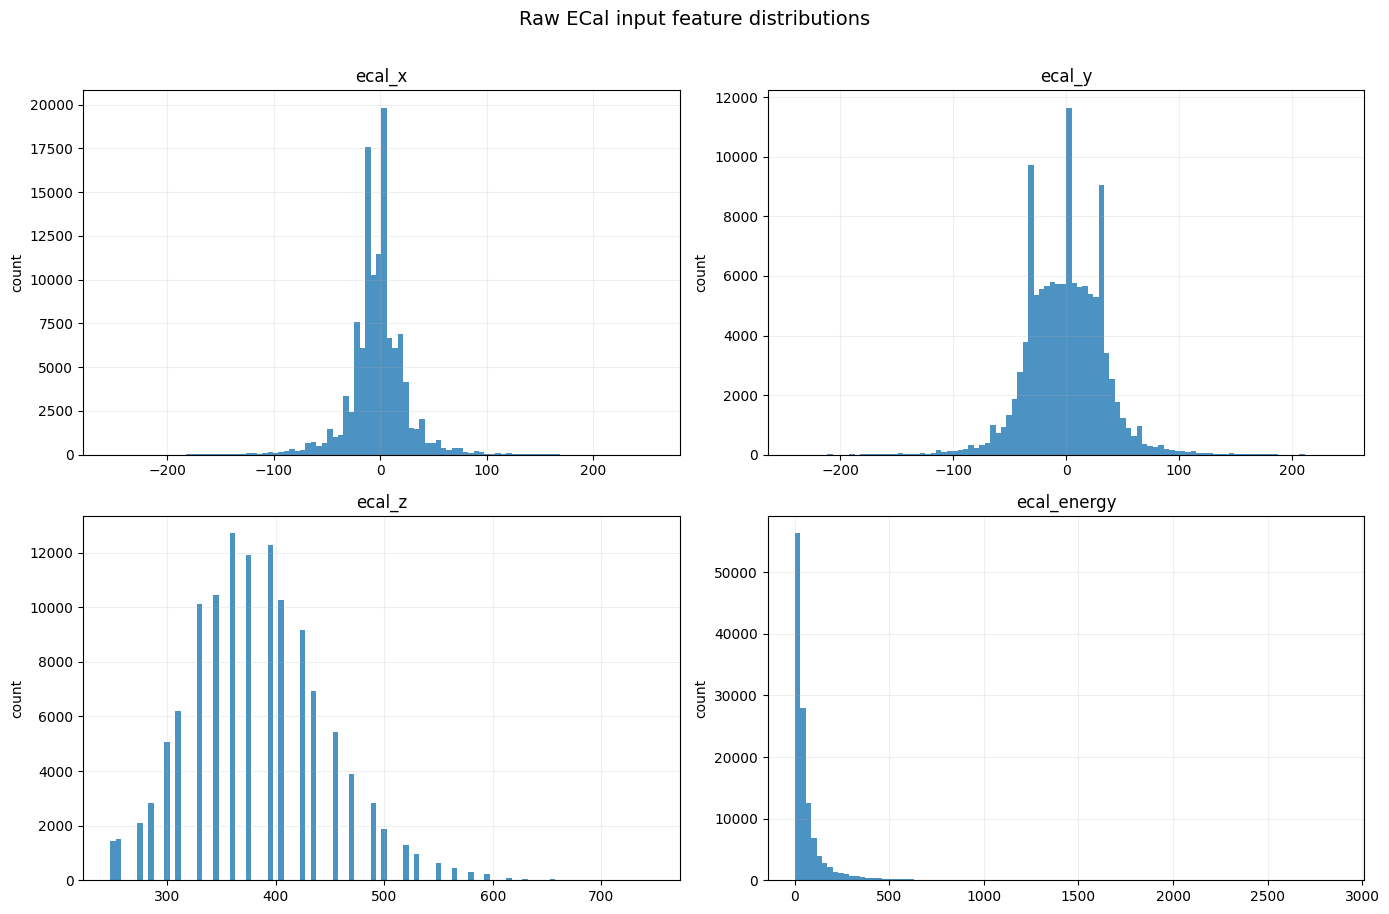

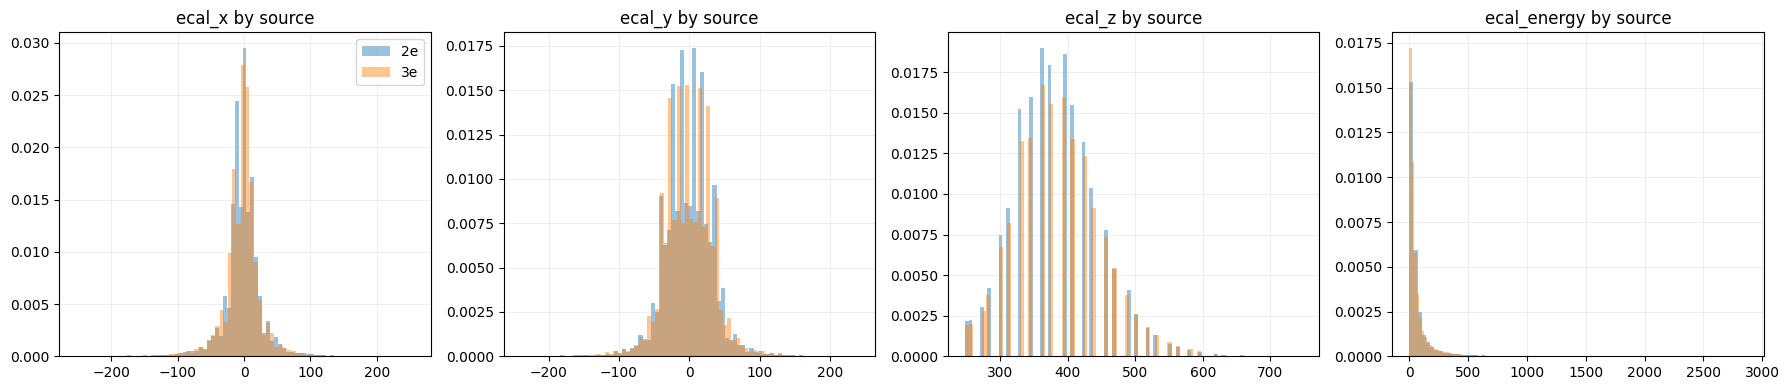

In [58]:
plot_hist_grid(
    ecal_df,
    ["ecal_x", "ecal_y", "ecal_z", "ecal_energy"],
    bins=100,
    title_prefix="Raw ECal input feature distributions",
    filename="ecal_raw_feature_distributions.png",
)
plt.show()

if "source_label" in ecal_df:
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    for ax, column in zip(axes, ["ecal_x", "ecal_y", "ecal_z", "ecal_energy"]):
        for label, group in ecal_df.groupby("source_label"):
            ax.hist(_safe_float_array(group[column]), bins=80, alpha=0.45, label=label, density=True)
        ax.set_title(f"{column} by source")
        ax.grid(alpha=0.2)
    axes[0].legend()
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / "ecal_raw_features_by_source.png", dpi=180, bbox_inches="tight")
    plt.show()

,transform,min,median,mean,p99,max,std,skew
0,raw,0.323195,31.749231,6.635237e+01,537.145142,2868.386230,102.245453,4.250051
1,log1p(clamp_min),0.280049,3.488879,3.566449e+00,6.288128,7.961853,1.103592,0.209899
2,sqrt(clamp_min),0.568503,5.634646,6.865859e+00,23.176392,53.557317,4.383190,1.878799
3,standard z-score,-0.645791,-0.338432,3.005576e-17,4.604535,27.404973,1.000000,4.250051
4,robust median/IQR,-0.577395,0.000000,6.357686e-01,9.285714,52.117954,1.878571,4.250051


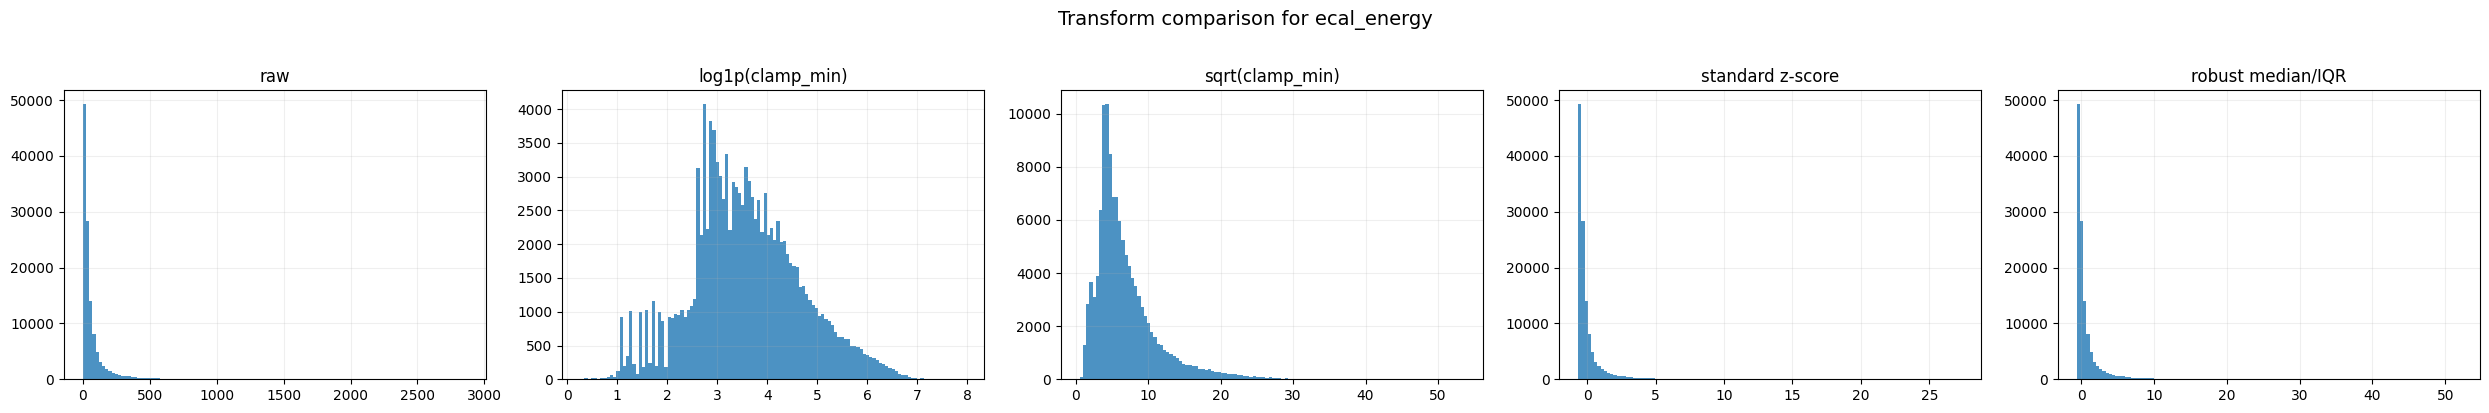

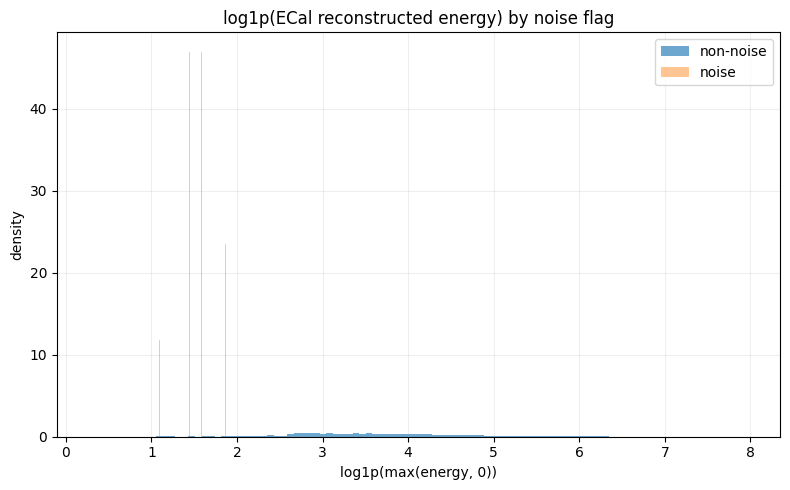

In [59]:
energy_transform_stats, _fig = plot_transform_comparison(
    ecal_df["ecal_energy"],
    "ecal_energy",
    bins=120,
    filename="ecal_energy_transform_comparison.png",
)
display(energy_transform_stats)

fig, ax = plt.subplots(figsize=(8, 5))
non_noise = ecal_df[~ecal_df["is_noise"]]
noise = ecal_df[ecal_df["is_noise"]]
ax.hist(log1p_nonnegative(non_noise["ecal_energy"]), bins=100, alpha=0.65, label="non-noise", density=True)
if len(noise):
    ax.hist(log1p_nonnegative(noise["ecal_energy"]), bins=100, alpha=0.45, label="noise", density=True)
ax.set_title("log1p(ECal reconstructed energy) by noise flag")
ax.set_xlabel("log1p(max(energy, 0))")
ax.set_ylabel("density")
ax.legend()
ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "ecal_energy_log1p_by_noise.png", dpi=180, bbox_inches="tight")
plt.show()

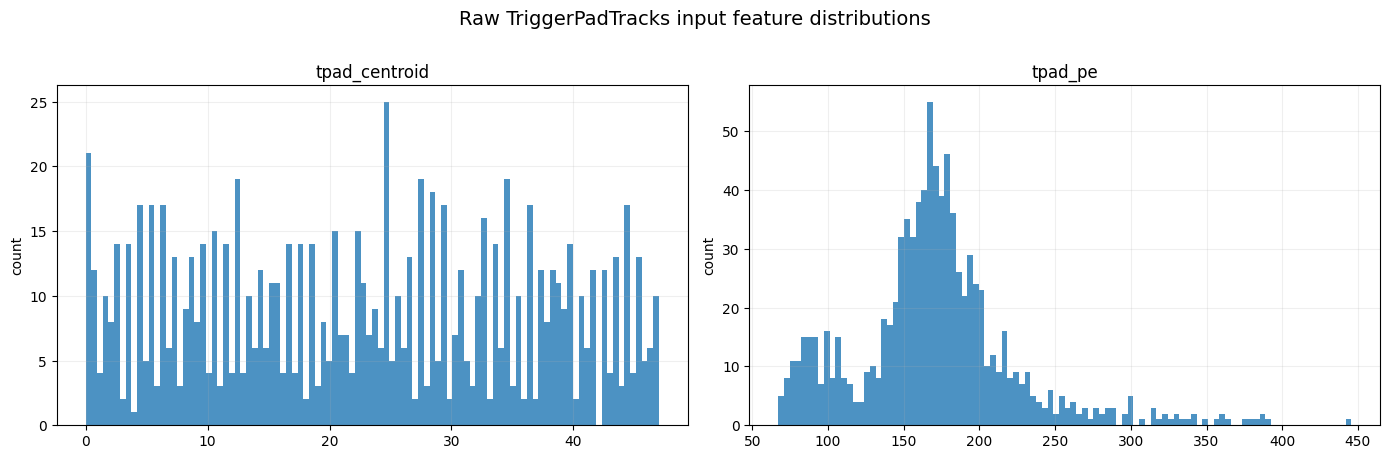

,transform,min,median,mean,p99,max,std,skew
0,raw,67.000000,169.000000,1.711239e+02,359.199993,445.666656,54.121592,0.989110
1,log1p(clamp_min),4.219508,5.135798,5.099026e+00,5.886654,6.101813,0.319287,-0.390949
2,sqrt(clamp_min),8.185353,13.000000,1.292222e+01,18.952548,21.110818,2.034744,0.253919
3,standard z-score,-1.923888,-0.039242,2.912060e-17,3.475067,5.072704,1.000000,0.989110
4,robust median/IQR,-2.185714,0.000000,4.551131e-02,4.075714,5.928571,1.159748,0.989110


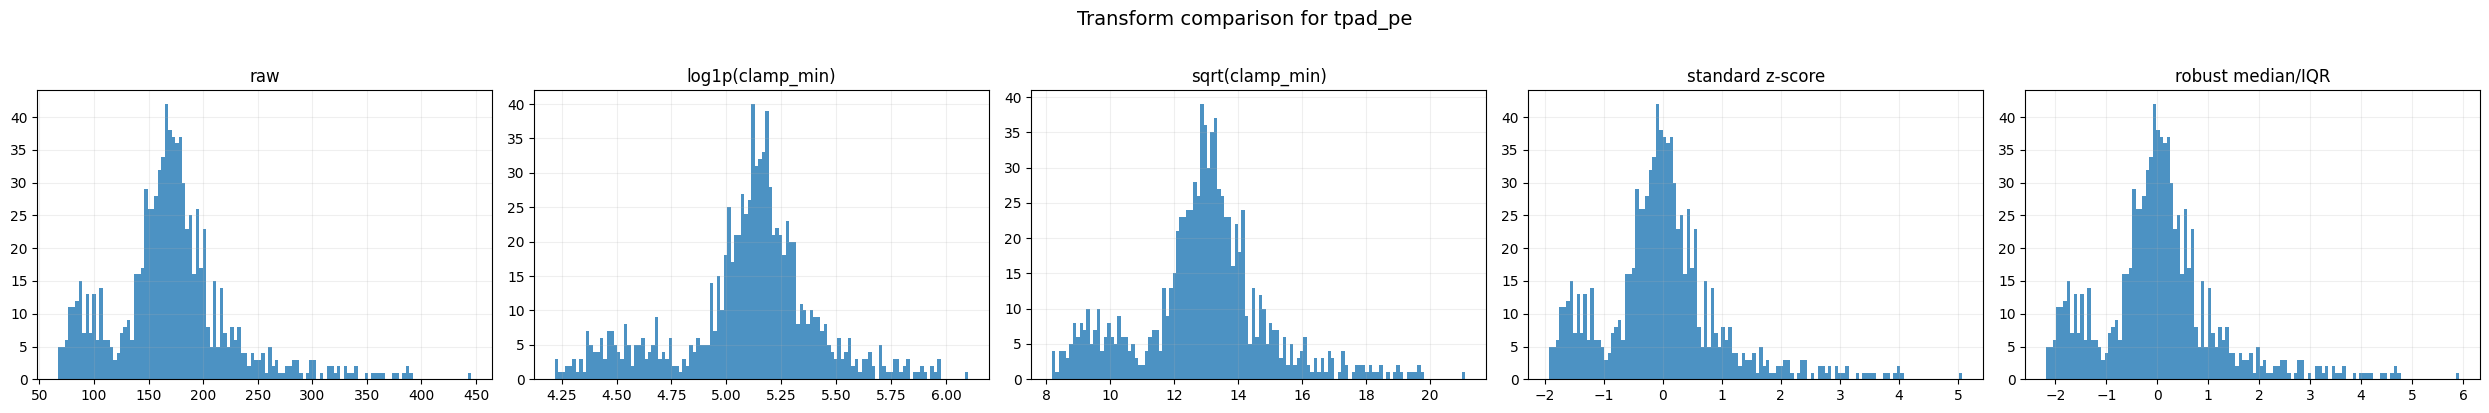

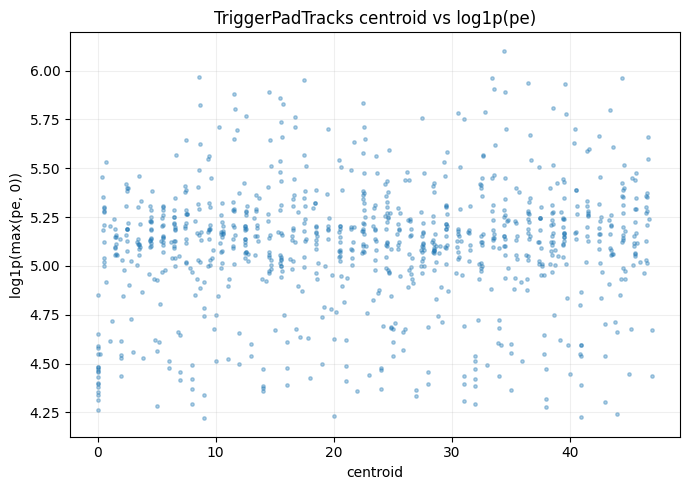

In [60]:
if len(tpad_df) == 0:
    print("No TriggerPadTracks rows were sampled.")
else:
    plot_hist_grid(
        tpad_df,
        ["tpad_centroid", "tpad_pe"],
        bins=100,
        title_prefix="Raw TriggerPadTracks input feature distributions",
        filename="tpad_raw_feature_distributions.png",
    )
    plt.show()

    pe_transform_stats, _fig = plot_transform_comparison(
        tpad_df["tpad_pe"],
        "tpad_pe",
        bins=120,
        filename="tpad_pe_transform_comparison.png",
    )
    display(pe_transform_stats)

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(tpad_df["tpad_centroid"], log1p_nonnegative(tpad_df["tpad_pe"]), s=6, alpha=0.35)
    ax.set_title("TriggerPadTracks centroid vs log1p(pe)")
    ax.set_xlabel("centroid")
    ax.set_ylabel("log1p(max(pe, 0))")
    ax.grid(alpha=0.2)
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / "tpad_centroid_vs_log1p_pe.png", dpi=180, bbox_inches="tight")
    plt.show()

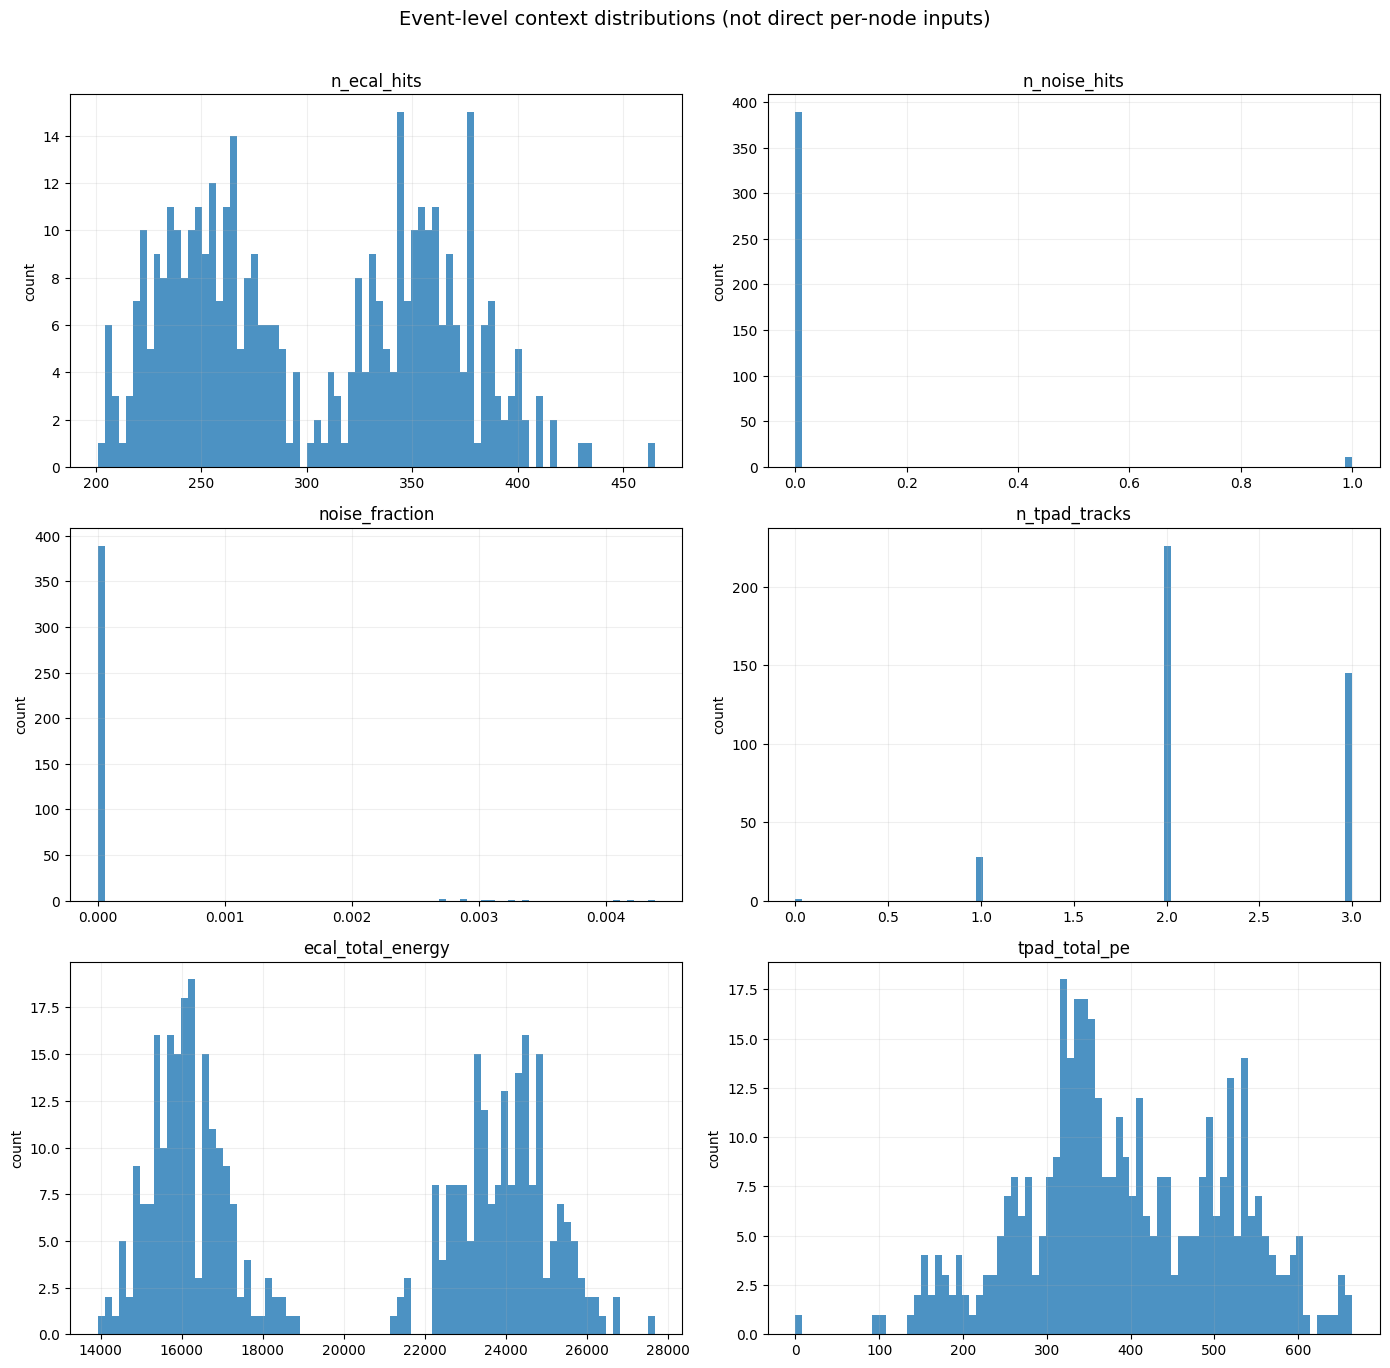

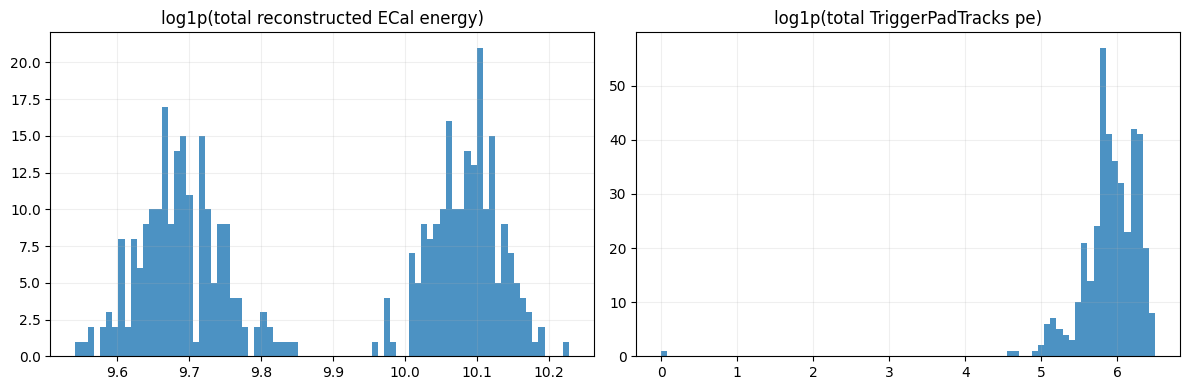

In [61]:
plot_hist_grid(
    event_df,
    ["n_ecal_hits", "n_noise_hits", "noise_fraction", "n_tpad_tracks", "ecal_total_energy", "tpad_total_pe"],
    bins=80,
    title_prefix="Event-level context distributions (not direct per-node inputs)",
    filename="event_level_distributions.png",
)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(log1p_nonnegative(event_df["ecal_total_energy"]), bins=80, alpha=0.8)
axes[0].set_title("log1p(total reconstructed ECal energy)")
axes[0].grid(alpha=0.2)
axes[1].hist(log1p_nonnegative(event_df["tpad_total_pe"]), bins=80, alpha=0.8)
axes[1].set_title("log1p(total TriggerPadTracks pe)")
axes[1].grid(alpha=0.2)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "event_level_log1p_totals.png", dpi=180, bbox_inches="tight")
plt.show()

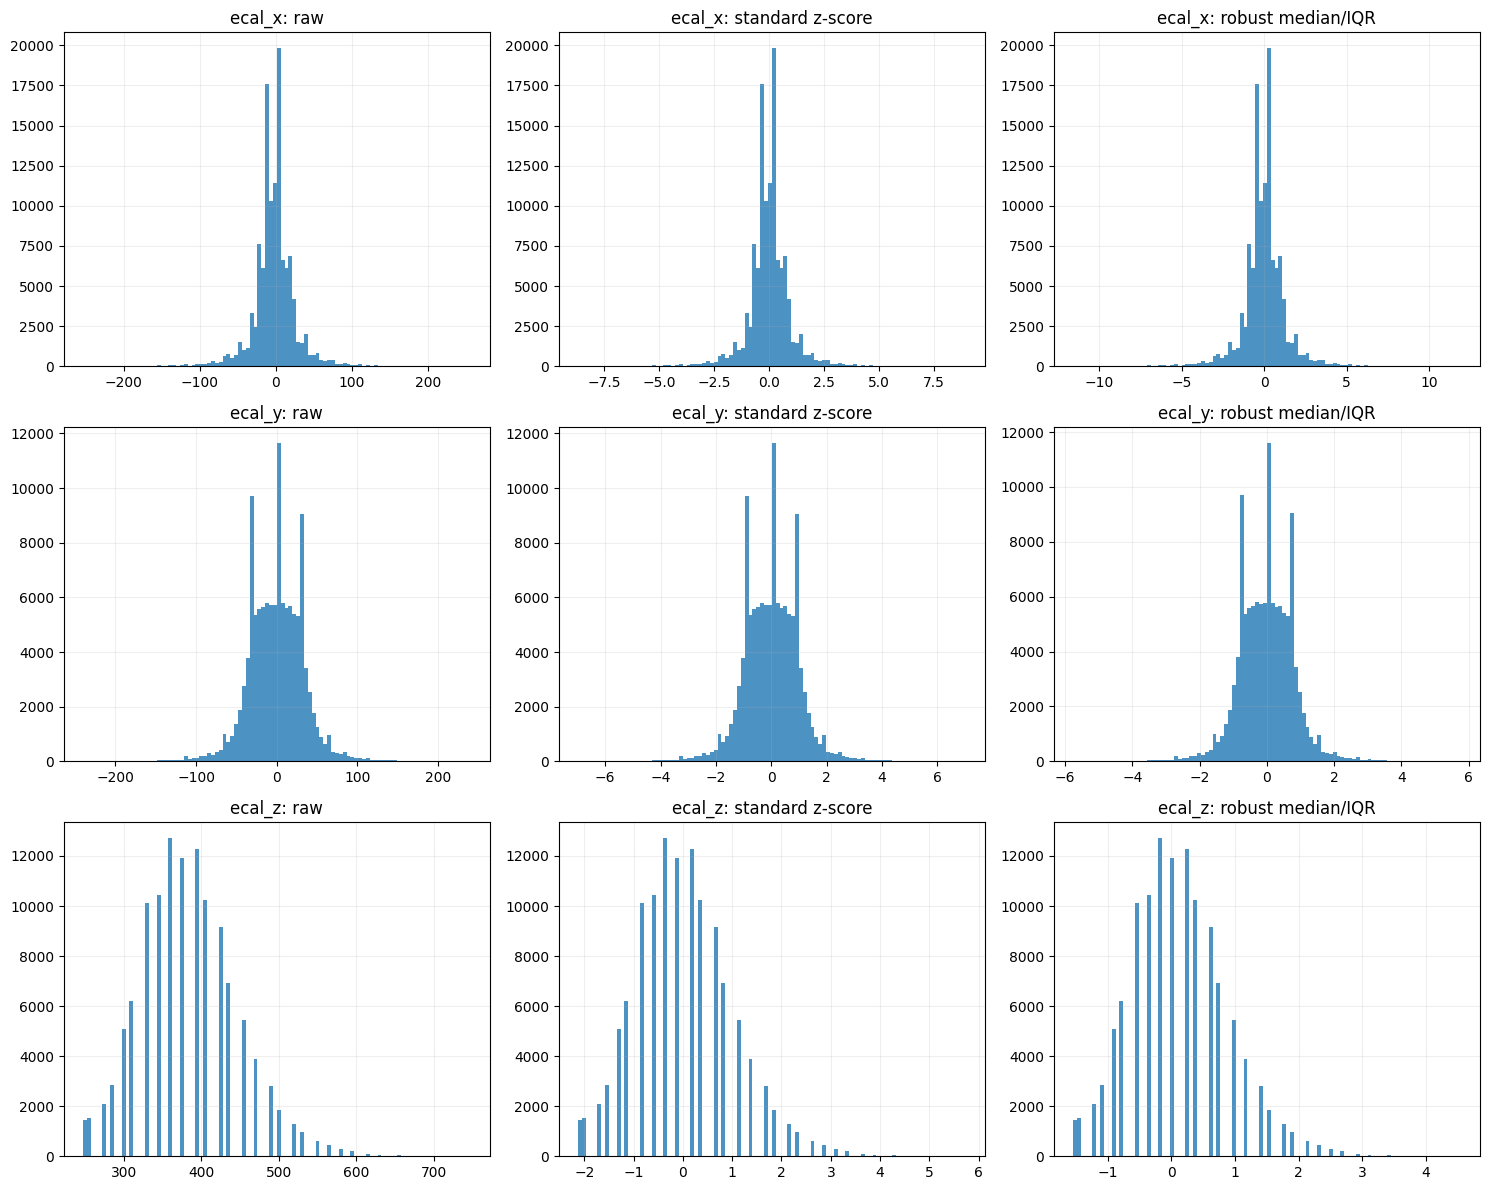

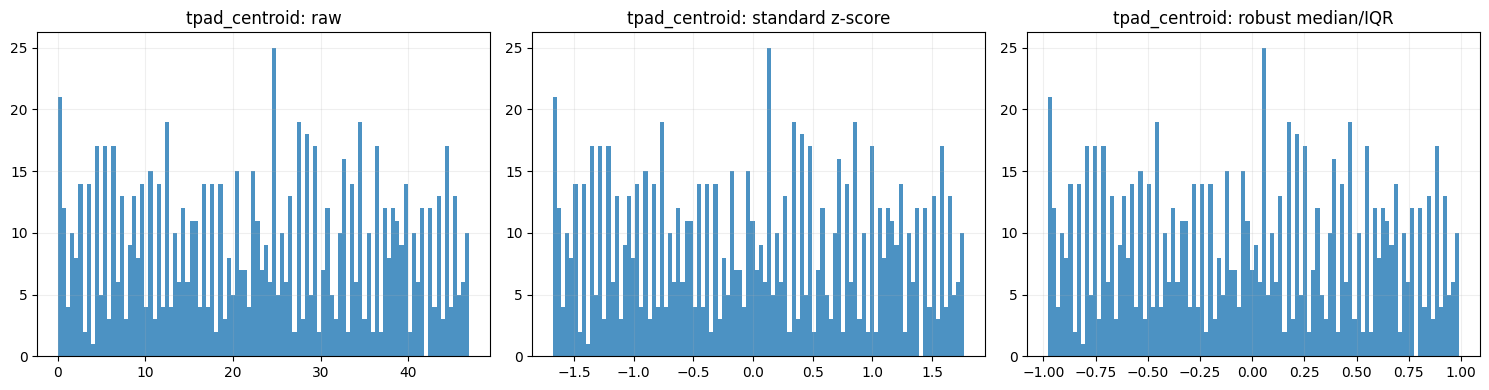

In [62]:
geometry_columns = ["ecal_x", "ecal_y", "ecal_z"]
fig, axes = plt.subplots(len(geometry_columns), 3, figsize=(15, 4 * len(geometry_columns)))
for row, column in enumerate(geometry_columns):
    raw = _safe_float_array(ecal_df[column])
    candidates = {
        "raw": raw,
        "standard z-score": standardize(raw),
        "robust median/IQR": robust_standardize(raw),
    }
    for ax, (name, values) in zip(axes[row], candidates.items()):
        ax.hist(values, bins=100, alpha=0.8)
        ax.set_title(f"{column}: {name}")
        ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "ecal_geometry_scaling_candidates.png", dpi=180, bbox_inches="tight")
plt.show()

if len(tpad_df):
    centroid = _safe_float_array(tpad_df["tpad_centroid"])
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, (name, values) in zip(
        axes,
        {
            "raw": centroid,
            "standard z-score": standardize(centroid),
            "robust median/IQR": robust_standardize(centroid),
        }.items(),
    ):
        ax.hist(values, bins=100, alpha=0.8)
        ax.set_title(f"tpad_centroid: {name}")
        ax.grid(alpha=0.2)
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / "tpad_centroid_scaling_candidates.png", dpi=180, bbox_inches="tight")
    plt.show()

In [63]:
recommendations = pd.DataFrame(
    [
        {
            "item": "ecal_energy",
            "recommended_shard_preprocessing": "log1p(clamp_min(x, 0))",
            "why": "right-skewed non-negative reconstructed energy; transform is event-independent and cheap to bake once",
            "caution": "record ecal_energy_transform=log1p in manifest; do not apply twice",
        },
        {
            "item": "tpad_pe",
            "recommended_shard_preprocessing": "decide after inspecting skew above; log1p is plausible",
            "why": "PE/intensity-like feature can be heavy-tailed like energy",
            "caution": "changing it requires adding a separate transform option, not reusing ecal_energy_transform silently",
        },
        {
            "item": "ecal_x/ecal_y/ecal_z/tpad_centroid",
            "recommended_shard_preprocessing": "usually keep raw in shards; normalize from training split or use fixed detector scaling later",
            "why": "coordinate centering/scaling depends on desired convention and train split; current training code already z-scores continuous columns",
            "caution": "if baked into shards, update docs/model feature contract so plots and physical coordinates are not confused",
        },
        {
            "item": "is_ecal/is_tpad",
            "recommended_shard_preprocessing": "none",
            "why": "binary detector type flags",
            "caution": "keep as 0/1 float32 for current models",
        },
        {
            "item": "truth labels, origin fractions, noise flags",
            "recommended_shard_preprocessing": "none as feature transforms",
            "why": "these are supervision targets or metadata, not input features",
            "caution": "target canonicalization/noise policy is a separate training/tensorization decision",
        },
    ]
)
recommendations

,item,recommended_shard_preprocessing,why,caution
0,ecal_energy,"log1p(clamp_min(x, 0))",right-skewed non-negative reconstructed energy...,record ecal_energy_transform=log1p in manifest...
1,tpad_pe,decide after inspecting skew above; log1p is p...,PE/intensity-like feature can be heavy-tailed ...,changing it requires adding a separate transfo...
2,ecal_x/ecal_y/ecal_z/tpad_centroid,usually keep raw in shards; normalize from tra...,coordinate centering/scaling depends on desire...,"if baked into shards, update docs/model featur..."
3,is_ecal/is_tpad,none,binary detector type flags,keep as 0/1 float32 for current models
4,"truth labels, origin fractions, noise flags",none as feature transforms,"these are supervision targets or metadata, not...",target canonicalization/noise policy is a sepa...


## Notes for Production Sharding

If the audit supports the transform choices, prefer rebuilding from ROOT into a new output cache instead of mutating old shards in place. Suggested layout:

```text
production_5M_001_sharded_log1p/
  2e/events/manifest.json
  2e/events/index.json
  2e/events/shards/*.pt
  3e/events/...
```

Before launching a full Cosmos job, run this notebook or the sharded preprocessor on a tiny sample and verify:

- `manifest.json` records the intended feature transforms.
- ECal feature column 5 is log-transformed only for ECal rows.
- TPAD rows are unchanged unless you intentionally add a TPAD PE transform.
- Target tensors and event counts match expectations.

## Thesis Figure: Raw vs log1p intensity feature distributions

This cell creates a compact 2x2 figure for the thesis report. The top row shows raw reconstructed ECal RecHit energy and TriggerPadTracks PE. The bottom row shows the same sampled values after `log1p(max(x, 0))`.

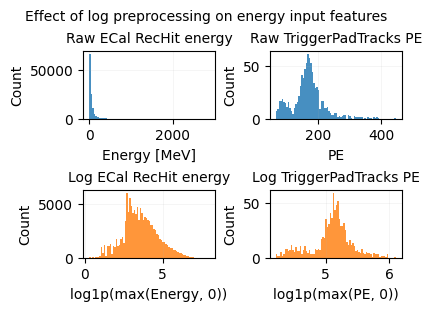

saved: /Users/eliotmontesinopetren/src/mpetren-msceng-ldmx/ml_ldmx/figures/notebooks/input_preprocessing_audit/log1p_2x2.png
ECal values: 121,041; TriggerPadTracks PE values: 915


In [81]:
# Thesis-ready 2x2 figure: raw and log1p-transformed intensity-like inputs.
import awkward as ak
import matplotlib.pyplot as plt
import numpy as np
import uproot
from pathlib import Path

THESIS_FIGURE_DIR = PROJECT_ROOT / "figures/notebooks/input_preprocessing_audit"
THESIS_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

THESIS_MAX_ROOT_FILES_PER_SOURCE = 2
THESIS_MAX_EVENTS_PER_ROOT_FILE = 200
THESIS_BINS = 80
THESIS_FIGSIZE = (4, 3)

ECAL_ENERGY_BRANCH = "EcalRecHits_overlay/EcalRecHits_overlay.energy_"
TPAD_PE_BRANCH = "TriggerPadTracks_overlay/TriggerPadTracks_overlay.pe_"
TREE_NAME = "LDMX_Events"


def sorted_root_files(source_dir):
    def numeric_key(path):
        suffix = path.stem.split("_")[-1]
        return (int(suffix) if suffix.isdigit() else 10**12, path.name)

    return sorted(Path(source_dir).glob("*.root"), key=numeric_key)


def finite_flattened(array):
    values = np.asarray(ak.to_numpy(ak.flatten(array, axis=None)), dtype=np.float64)
    return values[np.isfinite(values)]


ecal_parts = []
tpad_parts = []
for _electron_count, _source_label, source_dir in SOURCE_SPECS:
    for root_file in sorted_root_files(source_dir)[:THESIS_MAX_ROOT_FILES_PER_SOURCE]:
        with uproot.open(root_file) as handle:
            tree = handle[TREE_NAME]
            arrays = tree.arrays(
                [ECAL_ENERGY_BRANCH, TPAD_PE_BRANCH],
                entry_stop=THESIS_MAX_EVENTS_PER_ROOT_FILE,
                library="ak",
            )
        ecal_parts.append(finite_flattened(arrays[ECAL_ENERGY_BRANCH]))
        tpad_parts.append(finite_flattened(arrays[TPAD_PE_BRANCH]))

if not ecal_parts or sum(part.size for part in ecal_parts) == 0:
    raise RuntimeError("No ECal reconstructed energy values found.")
if not tpad_parts or sum(part.size for part in tpad_parts) == 0:
    raise RuntimeError("No TriggerPadTracks PE values found.")

ecal_energy = np.concatenate(ecal_parts)
tpad_pe = np.concatenate(tpad_parts)
ecal_energy_log1p = np.log1p(np.clip(ecal_energy, a_min=0.0, a_max=None))
tpad_pe_log1p = np.log1p(np.clip(tpad_pe, a_min=0.0, a_max=None))

with plt.rc_context(
    {
        "font.size": 10,
        "axes.titlesize": 10,
        "axes.labelsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
    }
):
    fig, axes = plt.subplots(2, 2, figsize=THESIS_FIGSIZE, constrained_layout=True)
    plot_specs = [
        (axes[0, 0], ecal_energy, "Raw ECal RecHit energy", "Energy [MeV]", "tab:blue"),
        (axes[0, 1], tpad_pe, "Raw TriggerPadTracks PE", "PE", "tab:blue"),
        (axes[1, 0], ecal_energy_log1p, "Log ECal RecHit energy", "log1p(max(Energy, 0))", "tab:orange"),
        (axes[1, 1], tpad_pe_log1p, "Log TriggerPadTracks PE", "log1p(max(PE, 0))", "tab:orange"),
    ]
    for ax, values, title, xlabel, color in plot_specs:
        ax.hist(values, bins=THESIS_BINS, color=color, alpha=0.82)
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Count")
        ax.grid(alpha=0.22, linewidth=0.4)
        ax.ticklabel_format(axis="y", style="plain", useOffset=False)

    fig.suptitle("Effect of log preprocessing on energy input features", fontsize=10)
    png_path = THESIS_FIGURE_DIR / "log1p_2x2.png"
    #pdf_path = THESIS_FIGURE_DIR / "thesis_log1p_ecal_energy_tpad_pe_2x2.pdf"
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    #fig.savefig(pdf_path, bbox_inches="tight")
    plt.show()

print(f"saved: {png_path}")
#print(f"saved: {pdf_path}")
print(f"ECal values: {ecal_energy.size:,}; TriggerPadTracks PE values: {tpad_pe.size:,}")